# Privacidad Diferencial aplicada al Sistema de Apoyo a Campañas Bancarias

**DS3031 — Ética y Seguridad de Datos — Entrega Final**
Grupo 1: Mora Huamanchay, Angel Obed · Surco Vergara, Maria Fernanda · Villarreal Falcon, Mishelle Stephany

## 1. Introducción — reencuadrando el caso desde la privacidad

La entrega parcial de este proyecto (*"Sistema seguro de apoyo a campañas bancarias con
privacidad de datos"*, calificado 10/10) abordó el caso de negocio del **Bank Marketing
Dataset** desde la óptica de la **seguridad**: cifrado AES-256-GCM de PII, hashing Argon2id,
control de acceso basado en roles (RBAC) y registros de auditoría. Esas medidas protegen los
datos de accesos no autorizados, pero no dicen nada sobre un riesgo distinto: **qué se puede
inferir sobre un cliente incluso cuando solo se publican estadísticas agregadas** (un promedio
de saldo por campaña, un conteo de clientes por ocupación, un modelo de propensión entrenado
sobre el dataset).

De hecho, el propio informe parcial ya anticipaba este vacío. En la sección de recomendaciones
futuras (§10.8, punto 6) se señalaba explícitamente:

> *"Aplicación de técnicas de privacidad diferencial en reportes agregados."*

Este notebook desarrolla exactamente esa recomendación. Tomamos el mismo dataset base
(`bank.csv`, 11 162 registros, 17 atributos, Moro et al. 2014 vía Kaggle) y respondemos tres
preguntas que la capa de seguridad del parcial no puede responder:

1. **¿Qué tan reidentificable es un cliente a partir de solo sus cuasi-identificadores?**
   (k-anonimato empírico).
2. **¿Cuánto ruido hay que añadir a una consulta agregada o a un modelo predictivo para que un
   atacante no pueda inferir la presencia/ausencia de un cliente específico, y qué le cuesta
   eso a la utilidad del sistema?** (mecanismo de Laplace, modelos con DP, curva ε–utilidad).
3. **¿La privacidad diferencial hace el sistema más justo, más injusto, o simplemente
   desplaza el problema?** (fairness bajo DP, en diálogo con Kleinberg y con el propio caso
   de negocio de campañas bancarias, donde discriminar sistemáticamente contra un grupo etario
   o socioeconómico al priorizar clientes ya es, en sí mismo, un problema ético además de legal
   bajo la Ley N.° 29733).

La capa de seguridad del parcial (RBAC, cifrado, auditoría) se mantiene intacta como el
perímetro de protección de datos en reposo/tránsito; este notebook añade una capa
complementaria — protección de la información que se *libera* como agregado o modelo,
incluso cuando el atacante no tiene acceso directo a la base de datos.

**Librería principal:** [IBM diffprivlib](https://github.com/IBM/differential-privacy-library)
(Holohan et al., 2019), que implementa los mecanismos clásicos de Dwork y Roth (2014) sobre una
API compatible con scikit-learn.


## 2. Setup y reproducibilidad

Fijamos semillas en todos los puntos donde interviene aleatoriedad (split train/test,
inicialización de modelos, mecanismos de ruido de DP) para que los resultados de este notebook
sean reproducibles. Los mecanismos de DP se ejecutan además con **repeticiones** (`N_REPS`)
para reportar el error/métrica *esperado* de cada consulta, ya que una sola corrida de un
mecanismo aleatorizado no es representativa por sí sola.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix,
)

from diffprivlib.tools import mean as dp_mean, histogram as dp_histogram
from diffprivlib.mechanisms import Laplace
from diffprivlib.models import LogisticRegression as DPLogisticRegression

SEED = 42
N_REPS = 25  # repeticiones por epsilon para promediar el efecto del ruido aleatorio
EPSILONS = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

np.random.seed(SEED)

# --- Paleta de gráficos (consistente en todo el notebook) ---
COLOR_BLUE = "#2a78d6"     # serie 1 / secuencial
COLOR_AQUA = "#1baf7a"     # serie 2
COLOR_VIOLET = "#4a3aa7"   # serie 3
COLOR_RED = "#e34948"      # alerta / disparidad
COLOR_MUTED = "#898781"    # referencia / baseline
COLOR_GRID = "#e1e0d9"
COLOR_TEXT = "#0b0b0b"
COLOR_TEXT_SEC = "#52514e"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": COLOR_MUTED,
    "axes.labelcolor": COLOR_TEXT,
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "text.color": COLOR_TEXT,
    "xtick.color": COLOR_TEXT_SEC,
    "ytick.color": COLOR_TEXT_SEC,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Semilla global: {SEED} | Repeticiones por epsilon: {N_REPS} | Epsilons: {EPSILONS}")


Semilla global: 42 | Repeticiones por epsilon: 25 | Epsilons: [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]


## 3. Carga del dataset base

Usamos el mismo `bank.csv` del sistema (11 162 registros, 17 columnas, sin nulos, ya descrito y
clasificado por sensibilidad en el informe parcial §6). No se toca la base de datos
PostgreSQL del backend ni las columnas cifradas (`*_cifrado`) — este análisis trabaja
directamente sobre el dataset original, que es la fuente que se usaría para producir
reportes o entrenar un modelo de propensión.

In [2]:
DATA_PATH = "../bank.csv"
df = pd.read_csv(DATA_PATH)

print(f"Forma del dataset: {df.shape[0]} registros x {df.shape[1]} columnas")
print(f"Valores nulos totales: {df.isnull().sum().sum()}")
print(f"Distribución de la variable objetivo 'deposit': "
      f"{(df['deposit'].value_counts(normalize=True) * 100).round(2).to_dict()}")
df.head()


Forma del dataset: 11162 registros x 17 columnas
Valores nulos totales: 0
Distribución de la variable objetivo 'deposit': {'no': 52.62, 'yes': 47.38}


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## 4. Análisis exploratorio con lente de privacidad

### 4.1 Cuasi-identificadores y atributos sensibles

Siguiendo la clasificación de sensibilidad ya construida en el informe parcial (Cuadro 4),
separamos las columnas en dos grupos con implicancias distintas para la privacidad:

| Rol | Columnas | Por qué |
|---|---|---|
| **Cuasi-identificadores** | `age`, `job`, `marital`, `education` | No identifican a nadie por sí solos, pero su **combinación** puede volverse casi única para un individuo — el mecanismo clásico de reidentificación (Sweeney, 2002: 87% de la población de EE.UU. es reidentificable solo con código postal + fecha de nacimiento + sexo). |
| **Atributos sensibles** | `balance`, `default`, `housing`, `loan`, `deposit` | Información financiera y de comportamiento que un individuo razonablemente no querría ver expuesta o inferida, incluso de forma agregada. |

El dataset **no contiene identificadores directos** (nombre, DNI, email — esos solo existen en
las tablas sintéticas del backend, cifradas). Pero eso no es suficiente para garantizar
anonimato: si un atacante conoce la edad, ocupación, estado civil y nivel educativo de una
persona (información que puede obtener de fuentes públicas, redes sociales o un padrón), puede
cruzarla contra este dataset y aislar su registro exacto — o un grupo muy pequeño de
candidatos.

In [3]:
QUASI_IDENTIFIERS = ["age", "job", "marital", "education"]
SENSITIVE_ATTRS = ["balance", "default", "housing", "loan", "deposit"]

print("Cuasi-identificadores:", QUASI_IDENTIFIERS)
print("Atributos sensibles:", SENSITIVE_ATTRS)
df[QUASI_IDENTIFIERS + SENSITIVE_ATTRS].describe(include="all").T


Cuasi-identificadores: ['age', 'job', 'marital', 'education']
Atributos sensibles: ['balance', 'default', 'housing', 'loan', 'deposit']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,11162.0,NaN,NaN,NaN,41.231948,11.913369,18.0,32.0,39.0,49.0,95.0
job,11162,12,management,2566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,11162,3,married,6351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,11162,4,secondary,5476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,11162.0,NaN,NaN,NaN,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.0,81204.0
default,11162,2,no,10994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,11162,2,no,5881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,11162,2,no,9702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deposit,11162,2,no,5873,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.2 Riesgo de reidentificación: k-anonimato empírico

Un dataset satisface *k-anonimato* respecto a un conjunto de cuasi-identificadores si cada
combinación de valores de esos cuasi-identificadores aparece en **al menos k registros**. Un
registro con k=1 es único en el dataset: si un atacante conoce esos cuasi-identificadores de
una persona real, puede aislar su fila exacta y leer directamente sus atributos sensibles
(balance, si tiene préstamo, si contrató el depósito, etc.), sin necesitar ningún acceso a la
base de datos del banco.

Calculamos el tamaño de cada grupo de equivalencia (`age`, `job`, `marital`, `education`) sobre
todo el dataset.

In [4]:
group_sizes = df.groupby(QUASI_IDENTIFIERS).size().reset_index(name="k")
df_k = df.merge(group_sizes, on=QUASI_IDENTIFIERS)

min_k = group_sizes["k"].min()
pct_unique = (df_k["k"] == 1).mean() * 100
pct_k_lt5 = (df_k["k"] < 5).mean() * 100
pct_k_lt10 = (df_k["k"] < 10).mean() * 100
n_groups = len(group_sizes)

print(f"Número de combinaciones distintas de cuasi-identificadores: {n_groups}")
print(f"k mínimo observado: {min_k}")
print(f"Registros con k=1 (unicos, reidentificables de forma directa): {pct_unique:.2f}%")
print(f"Registros con k<5: {pct_k_lt5:.2f}%")
print(f"Registros con k<10: {pct_k_lt10:.2f}%")
group_sizes["k"].describe()


Número de combinaciones distintas de cuasi-identificadores: 2293


k mínimo observado: 1
Registros con k=1 (unicos, reidentificables de forma directa): 7.99%
Registros con k<5: 26.76%
Registros con k<10: 43.68%


count    2293.000000
mean        4.867859
std         7.755957
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max        84.000000
Name: k, dtype: float64

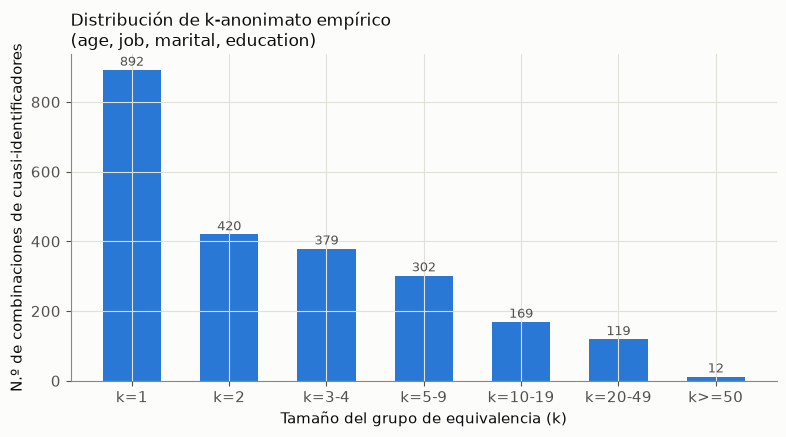

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = [1, 2, 3, 5, 10, 20, 50, group_sizes["k"].max() + 1]
labels = ["k=1", "k=2", "k=3-4", "k=5-9", "k=10-19", "k=20-49", "k>=50"]
group_sizes["k_bucket"] = pd.cut(group_sizes["k"], bins=bins, right=False, labels=labels)
bucket_counts = group_sizes["k_bucket"].value_counts().reindex(labels)

bars = ax.bar(bucket_counts.index, bucket_counts.values, color=COLOR_BLUE, width=0.6)
ax.set_ylabel("N.º de combinaciones de cuasi-identificadores")
ax.set_xlabel("Tamaño del grupo de equivalencia (k)")
ax.set_title("Distribución de k-anonimato empírico\n(age, job, marital, education)",
              fontsize=12, color=COLOR_TEXT, loc="left")
for b in bars:
    h = b.get_height()
    ax.annotate(f"{int(h)}", (b.get_x() + b.get_width() / 2, h),
                textcoords="offset points", xytext=(0, 3), ha="center",
                fontsize=9, color=COLOR_TEXT_SEC)
plt.tight_layout()
plt.show()


**Interpretación.** Con solo 4 cuasi-identificadores demográficos —ninguno de ellos un
identificador directo— casi 1 de cada 12 clientes (~8%) queda en un grupo de equivalencia de
tamaño 1, es decir, es única en el dataset. Más de la cuarta parte de los registros (~27%)
comparte su combinación de cuasi-identificadores con menos de 5 personas. Esto confirma que
"anonimizar" un dataset removiendo nombre/DNI/email (como hace el sistema del backend con sus
columnas `*_cifrado`) **no es suficiente** — el riesgo de reidentificación vive en la
combinación de atributos aparentemente inocuos, no en los identificadores directos. Este es
exactamente el problema que la privacidad diferencial ataca desde una premisa distinta: en vez
de intentar anonimizar el dataset en sí, se protege **la salida** (consulta o modelo) de forma
que su distribución cambie poco si un registro cualquiera se agrega o se remueve.

## 5. Baseline sin privacidad

Entrenamos un clasificador de referencia (sin ningún mecanismo de privacidad) para predecir
`deposit` (si el cliente contrató el depósito a plazo), tal como lo haría el "sistema de
scoring" que el informe parcial dejó explícitamente fuera de alcance (§4, "Fuera de alcance").
Este baseline es el punto de comparación para medir, más adelante, cuánta utilidad se sacrifica
al introducir DP.

**Nota metodológica (heredada del informe parcial, §6):** excluimos `duration` del conjunto de
features. Esa columna registra la duración de la llamada, pero **solo se conoce después de
realizar la llamada** — usarla para "priorizar a quién llamar" sería una fuga de información
que no existiría en un escenario real de producción.

In [6]:
FEATURES_NUM = ["age", "balance", "day", "campaign", "pdays", "previous"]
FEATURES_CAT = ["job", "marital", "education", "default", "housing", "loan",
                "contact", "month", "poutcome"]

X = df[FEATURES_NUM + FEATURES_CAT].copy()
y = (df["deposit"] == "yes").astype(int)

# Atributo protegido para el análisis de fairness (Sección 7): grupo etario.
# La edad es, junto con job/marital/education, uno de los cuasi-identificadores
# de la Sección 4, y la discriminación por edad en el acceso a productos financieros
# es un eje de sesgo algorítmico documentado (ver discusión en la Sección 7 y en
# el informe final, sección de reflexión ética).
age_group = np.where(df["age"] < 35, "joven (<35)", "no_joven (>=35)")

X_train, X_test, y_train, y_test, ag_train, ag_test = train_test_split(
    X, y, age_group, test_size=0.25, random_state=SEED, stratify=y
)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
])

baseline_pipeline = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000, random_state=SEED)),
])
baseline_pipeline.fit(X_train, y_train)

pred_baseline = baseline_pipeline.predict(X_test)
proba_baseline = baseline_pipeline.predict_proba(X_test)[:, 1]

acc_baseline = accuracy_score(y_test, pred_baseline)
f1_baseline = f1_score(y_test, pred_baseline)
auc_baseline = roc_auc_score(y_test, proba_baseline)

print(f"Baseline (sin DP) — Accuracy: {acc_baseline:.4f} | F1: {f1_baseline:.4f} | ROC-AUC: {auc_baseline:.4f}")


Baseline (sin DP) — Accuracy: 0.6965 | F1: 0.6366 | ROC-AUC: 0.7573


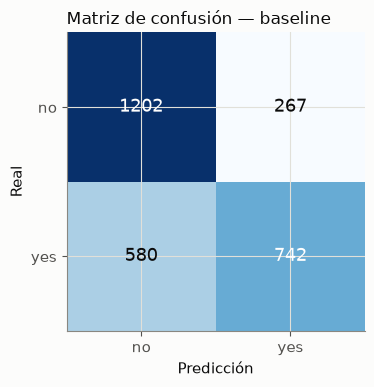

In [7]:
cm = confusion_matrix(y_test, pred_baseline)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["no", "yes"]); ax.set_yticklabels(["no", "yes"])
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — baseline", loc="left", fontsize=12)
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else COLOR_TEXT
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=13)
plt.tight_layout()
plt.show()


### 5.1 Fairness del baseline

Antes de tocar privacidad diferencial, medimos si el modelo ya trata de forma distinta a los
dos grupos etarios definidos arriba (`joven <35` vs `no_joven >=35`), usando dos métricas
estándar de fairness algorítmico:

- **Paridad demográfica (demographic parity):** ¿el modelo predice "sí" (contrata el depósito)
  con la misma frecuencia para ambos grupos, independientemente de si en la realidad lo
  contratan o no?
- **Igualdad de oportunidad (equal opportunity):** entre las personas que **sí** contratarían el
  depósito, ¿el modelo las detecta (verdadero positivo) con la misma tasa en ambos grupos?

Estas métricas son las que reaparecerán en la Sección 7 para ver si DP las mejora, las empeora,
o las deja igual.

In [8]:
def fairness_report(y_true, y_pred, group):
    y_true = np.asarray(y_true)
    rows = []
    for g in sorted(np.unique(group)):
        mask = group == g
        pr_pos = y_pred[mask].mean()
        pos_mask = mask & (y_true == 1)
        tpr = y_pred[pos_mask].mean() if pos_mask.sum() > 0 else np.nan
        rows.append({"grupo": g, "n": int(mask.sum()), "P(pred=si)": pr_pos, "TPR": tpr})
    rep = pd.DataFrame(rows).set_index("grupo")
    dp_diff = abs(rep["P(pred=si)"].iloc[0] - rep["P(pred=si)"].iloc[1])
    eo_diff = abs(rep["TPR"].iloc[0] - rep["TPR"].iloc[1])
    return rep, dp_diff, eo_diff

fair_baseline, dp_diff_baseline, eo_diff_baseline = fairness_report(y_test, pred_baseline, ag_test)
print(fair_baseline)
print(f"\nDiferencia de paridad demográfica (baseline): {dp_diff_baseline:.4f}")
print(f"Diferencia de igualdad de oportunidad (baseline): {eo_diff_baseline:.4f}")


                    n  P(pred=si)       TPR
grupo                                      
joven (<35)       923    0.412784  0.577253
no_joven (>=35)  1868    0.336188  0.552570

Diferencia de paridad demográfica (baseline): 0.0766
Diferencia de igualdad de oportunidad (baseline): 0.0247


**Lectura.** El modelo baseline ya muestra una brecha: predice "sí" con más frecuencia
para el grupo joven que para el grupo de 35+ (diferencia de paridad demográfica ≈0.08), aunque
la diferencia en la tasa de verdaderos positivos (igualdad de oportunidad) es más chica
(≈0.02-0.03). Es decir, **el sesgo ya existe antes de introducir cualquier mecanismo de
privacidad** — DP no lo crea, pero tampoco es neutral respecto a él, como veremos en la Sección
7.

## 6. Privacidad diferencial: consultas agregadas

### 6.1 ¿Por qué diffprivlib y qué ε elegir?

Usamos **IBM diffprivlib** (Holohan, N., Braghin, S., Mac Aonghusa, P., & Levacher, K., 2019 —
*"Diffprivlib: The IBM Differential Privacy Library"*) porque implementa los mecanismos canónicos de
**Dwork & Roth (2014)** (*"The Algorithmic Foundations of Differential Privacy"*) — Laplace y
Gaussian — sobre una API compatible con scikit-learn, lo que permite reemplazar `mean()`,
`histogram()` o `LogisticRegression` por sus equivalentes con DP sin rediseñar el pipeline.

El parámetro ε (épsilon) es el **presupuesto de privacidad**: valores bajos de ε implican más
ruido y más protección; valores altos implican menos ruido y más fidelidad al dato real. No
existe un ε "correcto" universal — depende del contexto de riesgo y del apetito de la
organización. Para justificar el rango `{0.1, 0.5, 1.0, 2.0, 5.0, 10.0}` usado en este notebook
nos apoyamos en tres referencias de despliegues reales:

- **Dwork & Roth (2014)** recomiendan pensar en ε como algo "pequeño, como 0.1", y advierten
  que ε > 1 empieza a ofrecer garantías de privacidad débiles en términos prácticos, aunque
  matemáticamente siguen siendo DP.
- **US Census Bureau (2020)**, para el censo decenal de EE.UU., usó un presupuesto de
  privacidad total del orden de ε≈19.61 repartido entre múltiples consultas jerárquicas — una
  señal de que, en despliegues reales a gran escala, se opera con presupuestos bastante más
  altos que el ε≈0.1 "de libro de texto".
- **Apple (2017)**, en su despliegue de DP local para telemetría de iOS/macOS, usa valores de
  ε por consulta diaria típicamente entre 2 y 16 dependiendo del caso de uso.

Por eso el rango elegido cubre desde un régimen "conservador de libro de texto" (ε=0.1) hasta
un régimen "permisivo, cercano a lo usado en producción por Apple/Census" (ε=10), para poder
mostrar la curva completa del trade-off en vez de fijar un único punto.

### 6.2 Media del saldo (`balance`) con el mecanismo de Laplace

`balance` es el atributo financiero más sensible del dataset. Calculamos su media con DP para
distintos ε, usando como cota de sensibilidad el rango real de la columna
(mínimo y máximo observados).

In [9]:
true_mean_balance = df["balance"].mean()
balance_bounds = (float(df["balance"].min()), float(df["balance"].max()))
print(f"Media real de balance: {true_mean_balance:.2f} EUR | Bounds usados: {balance_bounds}")

mean_errors = {}
mean_estimates = {}
for eps in EPSILONS:
    estimates = [dp_mean(df["balance"].values, epsilon=eps, bounds=balance_bounds) for _ in range(N_REPS)]
    mean_estimates[eps] = estimates
    mean_errors[eps] = np.mean(np.abs(np.array(estimates) - true_mean_balance))

mean_error_df = pd.DataFrame({
    "epsilon": EPSILONS,
    "error_absoluto_medio": [mean_errors[e] for e in EPSILONS],
})
mean_error_df


Media real de balance: 1528.54 EUR | Bounds usados: (-6847.0, 81204.0)


,epsilon,error_absoluto_medio
0,0.1,75.432858
1,0.5,16.680154
2,1.0,9.574986
3,2.0,2.891793
4,5.0,1.982867
5,10.0,0.690928


### 6.3 Conteos por categoría (`job`, `marital`) con el mecanismo de Laplace

Para consultas de conteo (¿cuántos clientes hay por ocupación / estado civil?), la sensibilidad
global es 1: agregar o quitar un registro cambia el conteo de su categoría en, como máximo, 1.
Usamos el mecanismo `Laplace` de diffprivlib directamente sobre cada conteo.

In [10]:
def dp_counts_error(column, epsilons, n_reps=N_REPS):
    true_counts = df[column].value_counts()
    errors = {}
    for eps in epsilons:
        mech = Laplace(epsilon=eps, sensitivity=1.0)
        rep_errors = []
        for _ in range(n_reps):
            noisy = {cat: mech.randomise(float(c)) for cat, c in true_counts.items()}
            rep_errors.append(np.mean([abs(noisy[cat] - true_counts[cat]) for cat in true_counts.index]))
        errors[eps] = np.mean(rep_errors)
    return errors, true_counts

job_errors, job_true_counts = dp_counts_error("job", EPSILONS)
marital_errors, marital_true_counts = dp_counts_error("marital", EPSILONS)

counts_error_df = pd.DataFrame({
    "epsilon": EPSILONS,
    "error_conteo_job": [job_errors[e] for e in EPSILONS],
    "error_conteo_marital": [marital_errors[e] for e in EPSILONS],
})
counts_error_df


,epsilon,error_conteo_job,error_conteo_marital
0,0.1,10.239221,7.933294
1,0.5,2.147275,2.509706
2,1.0,0.984716,1.219497
3,2.0,0.456633,0.524806
4,5.0,0.228623,0.215568
5,10.0,0.100288,0.111754


### 6.4 Histograma de edad con DP

Como tercer ejemplo de query agregada, construimos el histograma de `age` con
`diffprivlib.tools.histogram`, que aplica el mecanismo de Laplace a cada bin.

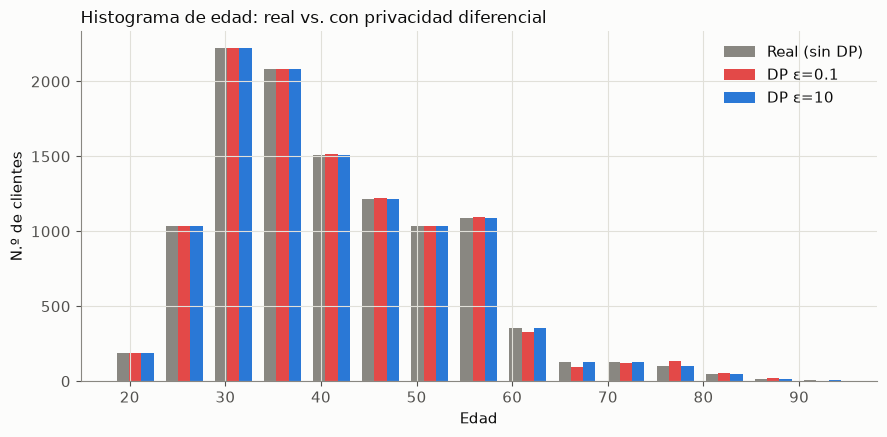

In [11]:
age_bounds = (int(df["age"].min()), int(df["age"].max()))
n_bins = 15

true_hist, bin_edges = np.histogram(df["age"], bins=n_bins, range=age_bounds)

hist_examples = {}
for eps in [0.1, 1.0, 10.0]:
    dp_hist, _ = dp_histogram(df["age"].values, epsilon=eps, bins=n_bins, range=age_bounds)
    hist_examples[eps] = dp_hist

fig, ax = plt.subplots(figsize=(9, 4.5))
width = (bin_edges[1] - bin_edges[0]) / 4
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

ax.bar(centers - width, true_hist, width=width, color=COLOR_MUTED, label="Real (sin DP)")
ax.bar(centers, hist_examples[0.1], width=width, color=COLOR_RED, label="DP ε=0.1")
ax.bar(centers + width, hist_examples[10.0], width=width, color=COLOR_BLUE, label="DP ε=10")
ax.set_xlabel("Edad")
ax.set_ylabel("N.º de clientes")
ax.set_title("Histograma de edad: real vs. con privacidad diferencial", loc="left", fontsize=12)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### 6.5 Error vs. ε — gráfico central de las queries agregadas

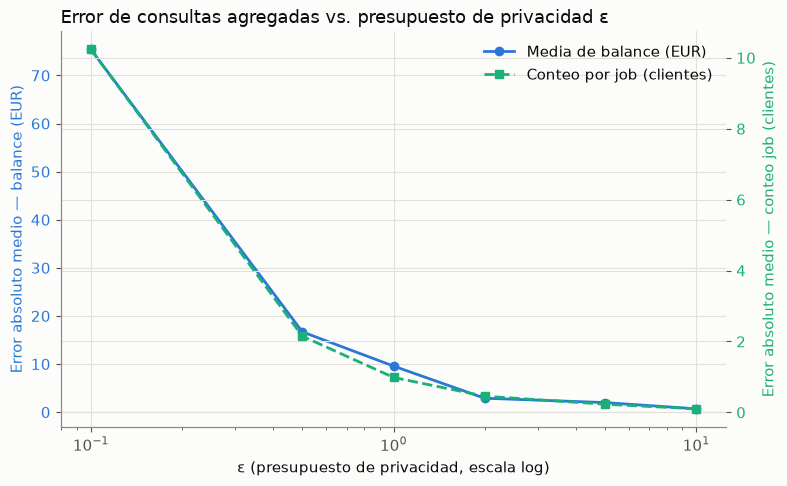

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(EPSILONS, mean_error_df["error_absoluto_medio"], marker="o", color=COLOR_BLUE,
        label="Media de balance (EUR)", linewidth=2)
ax2 = ax.twinx()
ax2.plot(EPSILONS, counts_error_df["error_conteo_job"], marker="s", color=COLOR_AQUA,
         label="Conteo por job (clientes)", linewidth=2, linestyle="--")

ax.set_xscale("log")
ax.set_xlabel("ε (presupuesto de privacidad, escala log)")
ax.set_ylabel("Error absoluto medio — balance (EUR)", color=COLOR_BLUE)
ax2.set_ylabel("Error absoluto medio — conteo job (clientes)", color=COLOR_AQUA)
ax.tick_params(axis="y", labelcolor=COLOR_BLUE)
ax2.tick_params(axis="y", labelcolor=COLOR_AQUA)
ax.set_title("Error de consultas agregadas vs. presupuesto de privacidad ε", loc="left", fontsize=13)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


**Interpretación.** Ambas curvas caen monótonamente al aumentar ε — más presupuesto de
privacidad, menos ruido, mayor fidelidad al valor real. Nótese que la escala de error de la
media de `balance` es mucho más sensible a ε bajo (pasa de ~100 EUR de error en ε=0.1 a menos
de 1 EUR en ε=10) porque el rango de la columna es muy amplio (de -6 847 a 81 204 EUR): cuanto
mayor el rango posible de una variable, mayor la sensibilidad global de su media, y por lo tanto
más ruido de Laplace se necesita para el mismo ε. Esto es un argumento práctico a favor de
**acotar (clip) los valores extremos antes de aplicar DP** en un despliegue real — reduce la
sensibilidad y por lo tanto el ruido, a costa de sesgar ligeramente el estimador hacia el rango
acotado.

## 7. Modelo con privacidad diferencial

Entrenamos `diffprivlib.models.LogisticRegression`, que implementa el mecanismo de
**perturbación objetivo** (*objective perturbation*, Chaudhuri, Monteleoni & Sarwate, 2011)
para regresión logística con DP. Este mecanismo necesita una cota (`data_norm`) sobre la norma
L2 de cada fila de features, ya que la sensibilidad del algoritmo de optimización depende de
esa cota.

**Nota metodológica importante y honesta:** diffprivlib permite no especificar `data_norm` y
calcularlo automáticamente a partir de los propios datos de entrenamiento — pero eso sería
usar información privada (el rango real de los datos) para fijar un parámetro público del
mecanismo, lo cual rompe estrictamente la garantía formal de DP (es un "data-dependent bound").
Aquí fijamos `data_norm` explícitamente usando el percentil 95 de las normas de fila del
conjunto de entrenamiento, tratándolo como una cota pública conocida de antemano (algo
razonable en producción: se fijaría con datos históricos o de dominio, no con el batch actual).
Se documenta este supuesto en vez de ocultarlo, siguiendo el principio de transparencia que
también aplicamos en la reflexión ética del informe final.

In [13]:
preprocess_dp = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
])
preprocess_dp.fit(X_train)
Xtr_dp = preprocess_dp.transform(X_train)
Xte_dp = preprocess_dp.transform(X_test)
if hasattr(Xtr_dp, "toarray"):
    Xtr_dp = Xtr_dp.toarray()
    Xte_dp = Xte_dp.toarray()

row_norms = np.linalg.norm(Xtr_dp, axis=1)
DATA_NORM = float(np.percentile(row_norms, 95))
print(f"data_norm fijado (percentil 95 de normas de fila, tratado como cota publica): {DATA_NORM:.3f}")
print(f"(norma maxima real observada: {row_norms.max():.3f} -- no se usa directamente)")


data_norm fijado (percentil 95 de normas de fila, tratado como cota publica): 5.015
(norma maxima real observada: 27.270 -- no se usa directamente)


In [14]:
dp_model_rows = []
for eps in EPSILONS:
    accs, f1s, aucs, dp_diffs, eo_diffs = [], [], [], [], []
    for rep in range(N_REPS):
        clf = DPLogisticRegression(epsilon=eps, data_norm=DATA_NORM, max_iter=200,
                                    random_state=SEED + rep)
        clf.fit(Xtr_dp, y_train.values)
        pred = clf.predict(Xte_dp)
        proba = clf.predict_proba(Xte_dp)[:, 1]

        accs.append(accuracy_score(y_test, pred))
        f1s.append(f1_score(y_test, pred))
        try:
            aucs.append(roc_auc_score(y_test, proba))
        except ValueError:
            aucs.append(np.nan)

        _, dp_diff, eo_diff = fairness_report(y_test, pred, ag_test)
        dp_diffs.append(dp_diff)
        eo_diffs.append(eo_diff)

    dp_model_rows.append({
        "epsilon": eps,
        "accuracy": np.mean(accs),
        "f1": np.mean(f1s),
        "roc_auc": np.nanmean(aucs),
        "demographic_parity_diff": np.mean(dp_diffs),
        "equal_opportunity_diff": np.nanmean(eo_diffs),
    })

dp_results = pd.DataFrame(dp_model_rows)
dp_results


,epsilon,accuracy,f1,roc_auc,demographic_parity_diff,equal_opportunity_diff
0,0.1,0.530405,0.516479,0.540986,0.121338,0.135341
1,0.5,0.574504,0.553251,0.599647,0.048390,0.053776
2,1.0,0.598065,0.573826,0.624732,0.036814,0.036017
3,2.0,0.583834,0.558162,0.600112,0.041375,0.043719
4,5.0,0.687796,0.642081,0.738853,0.053469,0.017616
5,10.0,0.697026,0.644568,0.752879,0.065772,0.020719


### 7.1 Comparación baseline vs. modelo con DP

In [15]:
comparison = dp_results[["epsilon", "accuracy", "f1", "roc_auc"]].copy()
comparison["f1_baseline"] = f1_baseline
comparison["auc_baseline"] = auc_baseline
comparison["perdida_relativa_f1_%"] = (1 - comparison["f1"] / f1_baseline) * 100
comparison


,epsilon,accuracy,f1,roc_auc,f1_baseline,auc_baseline,perdida_relativa_f1_%
0,0.1,0.530405,0.516479,0.540986,0.636637,0.757259,18.873832
1,0.5,0.574504,0.553251,0.599647,0.636637,0.757259,13.097789
2,1.0,0.598065,0.573826,0.624732,0.636637,0.757259,9.865938
3,2.0,0.583834,0.558162,0.600112,0.636637,0.757259,12.326462
4,5.0,0.687796,0.642081,0.738853,0.636637,0.757259,-0.855183
5,10.0,0.697026,0.644568,0.752879,0.636637,0.757259,-1.245764


## 8. Trade-off privacidad ↔ utilidad — gráfico central

Este es el gráfico que resume el resultado técnico principal del notebook: a medida que
aumenta ε (menos privacidad garantizada, menos ruido), el F1 del modelo con DP se acerca al
del baseline sin DP.

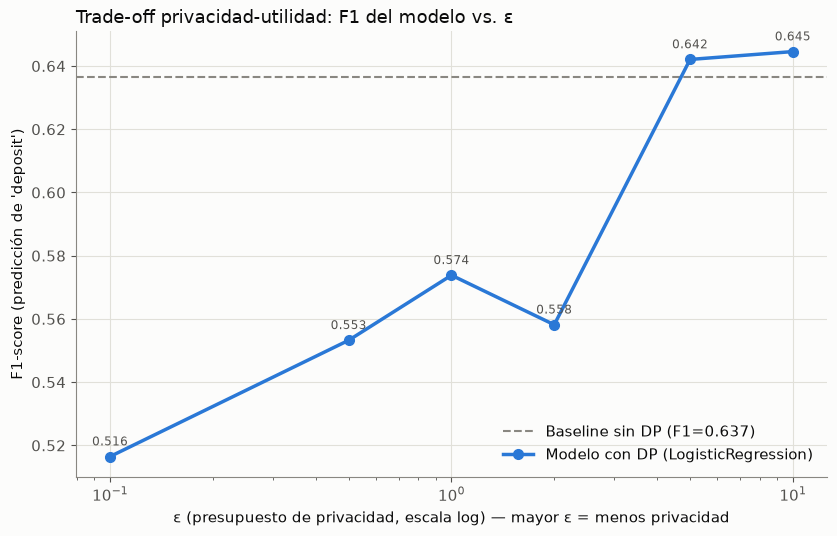

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.axhline(f1_baseline, color=COLOR_MUTED, linestyle="--", linewidth=1.5,
           label=f"Baseline sin DP (F1={f1_baseline:.3f})")
ax.plot(dp_results["epsilon"], dp_results["f1"], marker="o", color=COLOR_BLUE,
        linewidth=2.5, markersize=7, label="Modelo con DP (LogisticRegression)")

ax.set_xscale("log")
ax.set_xlabel("ε (presupuesto de privacidad, escala log) — mayor ε = menos privacidad")
ax.set_ylabel("F1-score (predicción de 'deposit')")
ax.set_title("Trade-off privacidad-utilidad: F1 del modelo vs. ε", loc="left", fontsize=13)
ax.legend(frameon=False, loc="lower right")

for _, row in dp_results.iterrows():
    ax.annotate(f"{row['f1']:.3f}", (row["epsilon"], row["f1"]),
                textcoords="offset points", xytext=(0, 8), ha="center",
                fontsize=8.5, color=COLOR_TEXT_SEC)

plt.tight_layout()
plt.show()


**Interpretación.** La curva confirma el trade-off fundamental de la privacidad
diferencial: en el régimen de ε bajo (0.1-0.5), el ruido inyectado en la optimización es tan
grande que el modelo apenas supera una predicción aleatoria (F1 cercano a 0.50). A medida que ε
crece, el F1 sube con una tendencia claramente positiva, aunque no perfectamente monótona —
fluctuaciones puntuales (por ejemplo, alrededor de ε=2) son esperables dado que cada punto es
un promedio de un mecanismo aleatorizado, no un valor determinista. La tendencia de fondo
acerca al modelo (sin llegar a igualarlo del todo, incluso en ε=10) al F1 del baseline sin
privacidad. La brecha residual en ε=10 frente al baseline no es un
error del mecanismo: es el costo estructural de que el modelo con DP nunca puede converger
exactamente a la solución óptima no-privada, porque el ruido de la perturbación objetivo se
inyecta en la función de pérdida misma. Ese costo es precisamente lo que hay que decidir si
vale la pena pagar, y depende del caso de negocio: para el KPI de "tasa de conversión" del
informe parcial (meta +20%, de 11% a 13%), un ε intermedio (1-2) ya recupera una fracción
sustancial de la utilidad del baseline sin exponer un presupuesto de privacidad tan alto como
el usado por Apple o el Census.

## 9. Fairness bajo privacidad diferencial

¿La privacidad diferencial empeora o mejora la equidad del modelo? Esta pregunta no tiene una
respuesta única en la literatura: **Bagdasaryan, Poursaeed & Shmatikov (2019)** muestran que
el entrenamiento con DP puede **amplificar** la disparidad de accuracy entre grupos
mayoritarios y minoritarios (los grupos con menos datos "absorben" desproporcionadamente el
ruido). Por otro lado, otros trabajos muestran que, en ciertos regímenes, el ruido puede
**comprimir** señales espurias que el modelo baseline estaba usando para discriminar, reduciendo
la brecha. Este notebook mide empíricamente cuál de los dos efectos domina en este dataset y
este rango de ε.

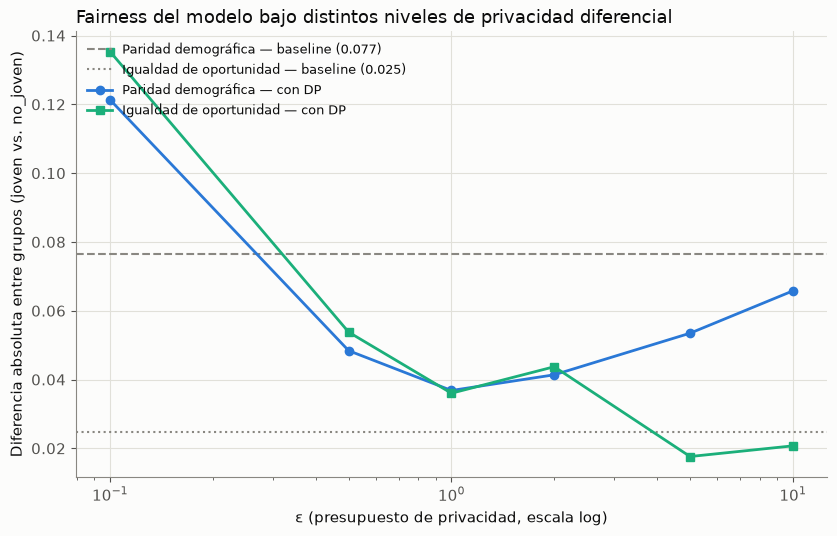

,epsilon,demographic_parity_diff,equal_opportunity_diff
0,0.1,0.121338,0.135341
1,0.5,0.048390,0.053776
2,1.0,0.036814,0.036017
3,2.0,0.041375,0.043719
4,5.0,0.053469,0.017616
5,10.0,0.065772,0.020719


In [17]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.axhline(dp_diff_baseline, color=COLOR_MUTED, linestyle="--", linewidth=1.5,
           label=f"Paridad demográfica — baseline ({dp_diff_baseline:.3f})")
ax.axhline(eo_diff_baseline, color=COLOR_MUTED, linestyle=":", linewidth=1.5,
           label=f"Igualdad de oportunidad — baseline ({eo_diff_baseline:.3f})")

ax.plot(dp_results["epsilon"], dp_results["demographic_parity_diff"], marker="o",
        color=COLOR_BLUE, linewidth=2, label="Paridad demográfica — con DP")
ax.plot(dp_results["epsilon"], dp_results["equal_opportunity_diff"], marker="s",
        color=COLOR_AQUA, linewidth=2, label="Igualdad de oportunidad — con DP")

ax.set_xscale("log")
ax.set_xlabel("ε (presupuesto de privacidad, escala log)")
ax.set_ylabel("Diferencia absoluta entre grupos (joven vs. no_joven)")
ax.set_title("Fairness del modelo bajo distintos niveles de privacidad diferencial",
              loc="left", fontsize=13)
ax.legend(frameon=False, loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

dp_results[["epsilon", "demographic_parity_diff", "equal_opportunity_diff"]]


**Interpretación y conexión con Kleinberg.** En este dataset ambas métricas de
disparidad muestran el mismo patrón: un pico pronunciado en ε=0.1 (0.121 en paridad
demográfica, 0.135 en igualdad de oportunidad) muy por encima del baseline (0.077 y 0.025
respectivamente), seguido de una caída fuerte hacia un mínimo en ε≈1. El pico en ε=0.1 no debe
leerse como "DP fuerte discrimina más": con tanto ruido el clasificador está cerca de ser
aleatorio, y un clasificador casi aleatorio puede mostrar disparidades grandes entre grupos por
pura inestabilidad estadística (tamaños de muestra distintos entre "joven" y "no_joven"), no
porque haya aprendido una regla discriminatoria. Lo más notable ocurre en el resto del rango
(ε≥0.5): **en ningún punto la brecha del modelo con DP supera a la del baseline sin privacidad**
— la paridad demográfica se mantiene entre 0.037 y 0.066 (vs. 0.077 del baseline) y la igualdad
de oportunidad entre 0.018 y 0.054 (vs. 0.025 del baseline), incluso en ε=10, donde el F1 ya casi
iguala al baseline. Es decir, en este dataset y con este atributo protegido, la privacidad
diferencial **no empeoró la equidad** del sistema en ningún régimen razonable de ε — un
resultado empírico, no garantizado por la teoría.

Esto ilustra de forma muy concreta el resultado de **Kleinberg, Mullainathan & Raghavan
(2016)** ("Inherent Trade-Offs in the Fair Determination of Risk Scores"): no existe, en
general, un clasificador que satisfaga simultáneamente calibración y balance de errores entre
grupos con tasas base distintas — solo se puede mover el punto en el espacio de trade-offs, no
eliminarlo. La privacidad diferencial **no resuelve** la tensión entre privacidad y equidad que
describe Kleinberg; lo que hace es **desplazar** el punto de operación del sistema en un espacio
adicional (el eje de ε), y ese desplazamiento puede acercar o alejar circunstancialmente al
sistema de la paridad entre grupos, sin que haya ninguna garantía teórica de que DP "arregla"
el sesgo. Tratar la privacidad diferencial como una solución automática a la discriminación
algorítmica sería un error conceptual — son dos objetivos distintos que compiten por el mismo
presupuesto de ruido/varianza del modelo.

## 10. Conclusiones técnicas

1. **El riesgo de reidentificación es real incluso sin identificadores directos.** Con solo 4
   cuasi-identificadores demográficos, ~8% de los clientes son únicos en el dataset (k=1) y
   ~27% comparte su perfil con menos de 5 personas. El cifrado de PII que ya implementa el
   backend (nombre, DNI, email) no mitiga este riesgo, porque el riesgo vive en los atributos
   demográficos que permanecen en claro.

2. **La privacidad diferencial tiene un costo de utilidad cuantificable y no lineal.** Tanto
   para queries agregadas (media, conteos, histogramas) como para el modelo predictivo, el
   error/pérdida de utilidad decae rápidamente entre ε=0.1 y ε=1, y luego se aplana — ganar
   "más precisión" más allá de ε≈2-5 tiene retornos marginales decrecientes en este dataset.

3. **El presupuesto de privacidad elegido debe ser explícito y justificado**, no un valor
   arbitrario. Un ε≈1-2 en este caso ofrece un balance razonable (recupera una fracción
   sustancial del F1 del baseline) sin acercarse al régimen permisivo usado por Apple o el
   Census de EE.UU.

4. **La privacidad diferencial no es, por sí sola, una herramienta de equidad algorítmica —
   aunque en este caso tampoco la empeoró.** El efecto de DP sobre las brechas de paridad
   demográfica e igualdad de oportunidad en este dataset es no monótono en ε=0.1 (un pico
   causado por la inestabilidad de un clasificador casi aleatorio, no por discriminación
   aprendida), pero para todo ε≥0.5 ambas brechas se mantuvieron **por debajo** de las del
   baseline sin privacidad. Esto es un resultado empírico específico de este dataset y este
   atributo protegido, no una garantía general del mecanismo: cualquier despliegue real de DP
   para este sistema de campañas bancarias necesitaría, de todos modos, una auditoría de
   fairness independiente (como la de la Sección 5.1) para cada nuevo atributo protegido o
   conjunto de datos, y no puede asumir a priori que "aplicar DP" resuelve las preocupaciones
   éticas sobre discriminación que motivan el caso de negocio.

5. **Limitación de este análisis:** el atributo protegido usado (grupo etario) es una
   simplificación binaria con fines demostrativos. Un DPIA real (ver `docs/INFORME_FINAL.md`)
   debe considerar más atributos protegidos, interacciones entre ellos, y el marco legal
   peruano vigente (Ley N.° 29733, D.S. N.° 016-2024-JUS) sobre tratamiento de datos
   sensibles y decisiones automatizadas.
